
--- PROCENTOWY ROZKŁAD RYZYKA ODPŁYWU W GRUPACH WIEKOWYCH ---
churn_risk   High Risk Low Risk Medium Risk
DRIV_AGE_BIN                               
18-21           97.69%    0.44%       1.87%
22-25           76.23%   12.47%       11.3%
26-30           41.86%   45.25%      12.89%
31-40            26.4%   64.42%       9.19%
41-50           19.42%   63.61%      16.97%
51-60           13.27%   69.35%      17.38%
61-70            8.09%   83.41%       8.49%
70+              16.9%   49.76%      33.34%


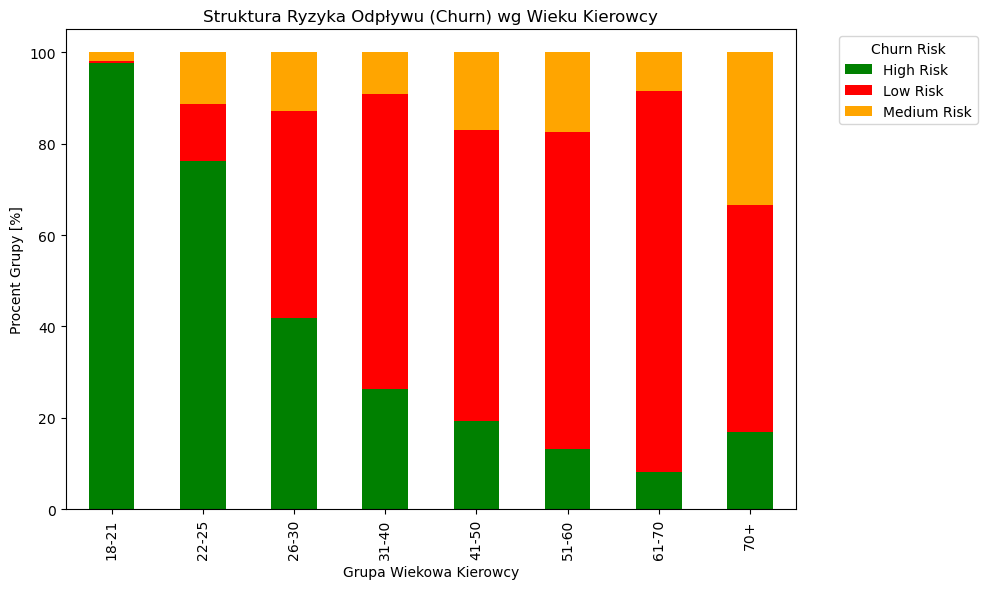

In [75]:
# Tworzymy tabelę przestawną: Wiek Kierowcy vs Ryzyko Churnu
churn_by_age = pd.crosstab(
    merged['DRIV_AGE_BIN'], 
    merged['churn_risk'], 
    normalize='index'  # Zamieniamy na procenty wewnątrz każdej grupy wiekowej
) * 100

# Wyświetlamy wyniki
print("\n--- PROCENTOWY ROZKŁAD RYZYKA ODPŁYWU W GRUPACH WIEKOWYCH ---")
print(churn_by_age.round(2).astype(str) + '%')

# Wizualizacja
churn_by_age.plot(kind='bar', stacked=True, figsize=(10, 6), 
                  color=['green', 'red', 'orange']) # Dopasowanie kolorów do ryzyka
plt.title("Struktura Ryzyka Odpływu (Churn) wg Wieku Kierowcy")
plt.ylabel("Procent Grupy [%]")
plt.xlabel("Grupa Wiekowa Kierowcy")
plt.legend(title="Churn Risk", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\wertg\AppData\Local\Temp\ipykernel_23120\407201202.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby("DRIV_AGE_BIN")["ANNUAL_PREMIUM"].mean().plot(kind="bar", color="skyblue", figsize=(10,5))


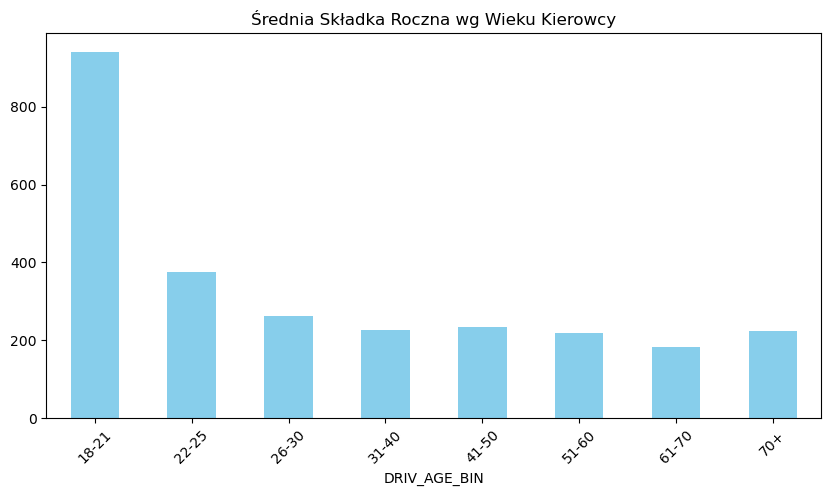

In [76]:
# Szybki wykres taryfy wg grup wiekowych
merged.groupby("DRIV_AGE_BIN")["ANNUAL_PREMIUM"].mean().plot(kind="bar", color="skyblue", figsize=(10,5))
plt.title("Średnia Składka Roczna wg Wieku Kierowcy")
plt.ylabel("")
plt.xticks(rotation=45)
plt.show()

In [77]:
# ==========================================
# 13. ZBIORCZY RAPORT TARYFOWY (EXECUTIVE SUMMARY)
# ==========================================

# Obliczamy faktyczne straty (szkody) na polisę
merged['actual_losses'] = merged['CLAIM_TOTAL_AMOUNT']

# Grupowanie wszystkich kluczowych metryk
executive_summary = merged.groupby('DRIV_AGE_BIN', observed=True).agg({
    'EXPOSURE': 'sum',
    'EARNED_PREMIUM': 'sum',           # Łączny przypis (Earned)
    'ANNUAL_PREMIUM': ['mean', 'median'], # Taryfa (nasz cennik)
    'actual_losses': 'sum'            # Ile wypłaciliśmy
}).reset_index()

# Spłaszczanie nazw kolumn dla czytelności
executive_summary.columns = [
    'Grupa_Wieku', 'Suma_Ekspozycji', 'Przypis_Zarobiony', 
    'Srednia_Taryfa_Roczna', 'Mediana_Taryfa_Roczna', 'Suma_Szkod'
]

# Obliczamy Loss Ratio (LR) dla każdej grupy
executive_summary['Loss_Ratio'] = (executive_summary['Suma_Szkod'] / executive_summary['Przypis_Zarobiony']).round(4)

# Formatowanie wyników do wyświetlenia
report = executive_summary.copy()
for col in ['Przypis_Zarobiony', 'Srednia_Taryfa_Roczna', 'Mediana_Taryfa_Roczna', 'Suma_Szkod']:
    report[col] = report[col].map('{:,.2f} $'.format)

report['Loss_Ratio'] = (report['Loss_Ratio'] * 100).map('{:.2f}%'.format)

print("\n" + "="*80)
print("ZBIORCZY RAPORT PORTFELA UBEZPIECZENIOWEGO")
print("="*80)
print(report.to_string(index=False))


ZBIORCZY RAPORT PORTFELA UBEZPIECZENIOWEGO
Grupa_Wieku  Suma_Ekspozycji Przypis_Zarobiony Srednia_Taryfa_Roczna Mediana_Taryfa_Roczna      Suma_Szkod Loss_Ratio
      18-21      4166.231937    3,816,340.79 $              941.33 $              891.15 $  9,396,765.34 $    246.22%
      22-25     11084.351680    3,995,598.32 $              375.48 $              328.05 $  2,561,068.22 $     64.10%
      26-30     27480.311097    6,788,970.76 $              263.33 $              222.40 $  4,668,236.53 $     68.76%
      31-40     79136.097969   16,720,976.04 $              226.77 $              177.99 $ 11,864,444.91 $     70.96%
      41-50    100387.561945   22,161,122.30 $              233.19 $              193.99 $ 13,695,346.41 $     61.80%
      51-60     70950.090228   14,956,561.85 $              218.85 $              194.28 $  9,206,525.58 $     61.56%
      61-70     35759.943346    6,363,477.58 $              184.23 $              164.11 $  4,345,023.74 $     68.28%
        70+ 

In [78]:
# ==========================================
# KPI: MTPL PRODUCT PERFORMANCE (CORRECTED FOR EXPOSURE)
# ==========================================

# 1) KPI wg specyfikacji (5% marży zysku od całości)
# (Full + Variable) / 0.95 daje 5% marży
merged['MTPL_offered_premium'] = (merged['FullActuarialCost'] + merged['VariableCost']) / 0.95

# 2) Marża kwotowa (roczna)
merged['MTPL_offered_margin'] = (
    merged['MTPL_offered_premium']
    - merged['FullActuarialCost']
    - merged['VariableCost']
)

# 3) EARNED (zarobione) wielkości: annual * exposure
merged["MTPL_EARNED_PREMIUM"] = merged["MTPL_offered_premium"] * merged["EXPOSURE"]
merged["MTPL_EARNED_MARGIN"]  = merged["MTPL_offered_margin"]  * merged["EXPOSURE"]

# Jeśli VariableCost jest roczne (u Ciebie jest), do Combined Ratio earned musi być też earned:
merged["EARNED_VariableCost"] = merged["VariableCost"] * merged["EXPOSURE"]

# (Opcjonalnie) Expected losses earned (jeśli chcesz osobno KPI "expected/model-based")
merged["EARNED_BaseCost"] = merged["BaseActuarialCost"] * merged["EXPOSURE"]

# 4) Grupowanie danych KPI
kpi_summary = merged.groupby('DRIV_AGE_BIN', observed=True).agg({
    'MTPL_offered_premium': 'mean',        # średnia roczna stawka (cennik)
    'MTPL_EARNED_PREMIUM': 'sum',          # zarobiona składka (baza do LR/CR)
    'MTPL_EARNED_MARGIN': 'sum',           # łączna zarobiona marża
    'CLAIM_TOTAL_AMOUNT': 'sum',           # faktyczne szkody (historyczne)
    'EARNED_VariableCost': 'sum',          # zarobione koszty zmienne
    'EXPOSURE': 'sum'                      # kontrolnie
}).reset_index()

# 5) Wskaźniki na EARNED PREMIUM (ACTUAL)
kpi_summary['MTPL_offered_loss_ratio'] = (
    kpi_summary['CLAIM_TOTAL_AMOUNT'] / kpi_summary['MTPL_EARNED_PREMIUM']
)

kpi_summary['MTPL_offered_combined_ratio'] = (
    (kpi_summary['CLAIM_TOTAL_AMOUNT'] + kpi_summary['EARNED_VariableCost'])
    / kpi_summary['MTPL_EARNED_PREMIUM']
)

# 6) Raport do wyświetlenia
report_kpi = kpi_summary[[
    'DRIV_AGE_BIN',
    'MTPL_offered_premium',
    'MTPL_EARNED_PREMIUM',
    'MTPL_EARNED_MARGIN',
    'MTPL_offered_loss_ratio',
    'MTPL_offered_combined_ratio'
]].copy()

# Formatowanie
report_kpi['MTPL_offered_premium'] = report_kpi['MTPL_offered_premium'].map('{:,.2f} $'.format)
report_kpi['MTPL_EARNED_PREMIUM']  = report_kpi['MTPL_EARNED_PREMIUM'].map('{:,.2f} $'.format)
report_kpi['MTPL_EARNED_MARGIN']   = report_kpi['MTPL_EARNED_MARGIN'].map('{:,.2f} $'.format)
report_kpi['MTPL_offered_loss_ratio'] = (report_kpi['MTPL_offered_loss_ratio'] * 100).map('{:.2f}%'.format)
report_kpi['MTPL_offered_combined_ratio'] = (report_kpi['MTPL_offered_combined_ratio'] * 100).map('{:.2f}%'.format)

print("\n" + "="*95)
print("RAPORT KPI: MTPL PRODUCT PERFORMANCE (ACTUAL, CORRECTED FOR EXPOSURE)")
print("="*95)
print(report_kpi.to_string(index=False))


# ==========================================
# (OPCJONALNIE) KPI EXPECTED / MODEL-BASED
# ==========================================

kpi_expected = merged.groupby('DRIV_AGE_BIN', observed=True).agg({
    'MTPL_EARNED_PREMIUM': 'sum',
    'EARNED_BaseCost': 'sum',
    'EARNED_VariableCost': 'sum'
}).reset_index()

kpi_expected['Expected_Loss_Ratio'] = kpi_expected['EARNED_BaseCost'] / kpi_expected['MTPL_EARNED_PREMIUM']
kpi_expected['Expected_Combined_Ratio'] = (
    (kpi_expected['EARNED_BaseCost'] + kpi_expected['EARNED_VariableCost'])
    / kpi_expected['MTPL_EARNED_PREMIUM']
)

report_kpi_exp = kpi_expected[[
    'DRIV_AGE_BIN',
    'Expected_Loss_Ratio',
    'Expected_Combined_Ratio'
]].copy()

report_kpi_exp['Expected_Loss_Ratio'] = (report_kpi_exp['Expected_Loss_Ratio'] * 100).map('{:.2f}%'.format)
report_kpi_exp['Expected_Combined_Ratio'] = (report_kpi_exp['Expected_Combined_Ratio'] * 100).map('{:.2f}%'.format)

print("\n" + "="*95)
print("RAPORT KPI: MTPL PRODUCT PERFORMANCE (EXPECTED, MODEL-BASED)")
print("="*95)
print(report_kpi_exp.to_string(index=False))



RAPORT KPI: MTPL PRODUCT PERFORMANCE (ACTUAL, CORRECTED FOR EXPOSURE)
DRIV_AGE_BIN MTPL_offered_premium MTPL_EARNED_PREMIUM MTPL_EARNED_MARGIN MTPL_offered_loss_ratio MTPL_offered_combined_ratio
       18-21             991.06 $      4,017,594.62 $       200,879.73 $                 233.89%                     262.39%
       22-25             395.25 $      4,205,919.82 $       210,295.99 $                  60.89%                      89.39%
       26-30             277.21 $      7,146,580.96 $       357,329.05 $                  65.32%                      93.82%
       31-40             238.70 $     17,600,874.81 $       880,043.74 $                  67.41%                      95.91%
       41-50             245.45 $     23,327,179.02 $     1,166,358.95 $                  58.71%                      87.21%
       51-60             230.37 $     15,743,828.44 $       787,191.42 $                  58.48%                      86.98%
       61-70             193.93 $      6,698,380.28 $ 


SUROWE STATYSTYKI PORTFELA (FAKTY HISTORYCZNE)
Grupa_Wieku  Liczba_Polis  Liczba_Wypadkow  Suma_Kosztow_Szkod  %_Wypadkowosc  Srednia_Szkoda
      18-21         10665            832.0          9396765.34           7.80        11294.19
      22-25         25892           1291.0          2561068.22           4.99         1983.79
      26-30         61703           2087.0          4668236.53           3.38         2236.82
      31-40        159947           5103.0         11864444.91           3.19         2324.99
      41-50        188152           7177.0         13695346.41           3.81         1908.23
      51-60        126419           4651.0          9206525.58           3.68         1979.47
      61-70         59630           2126.0          4345023.74           3.57         2043.76
        70+         36489           1471.0          4056955.75           4.03         2757.96


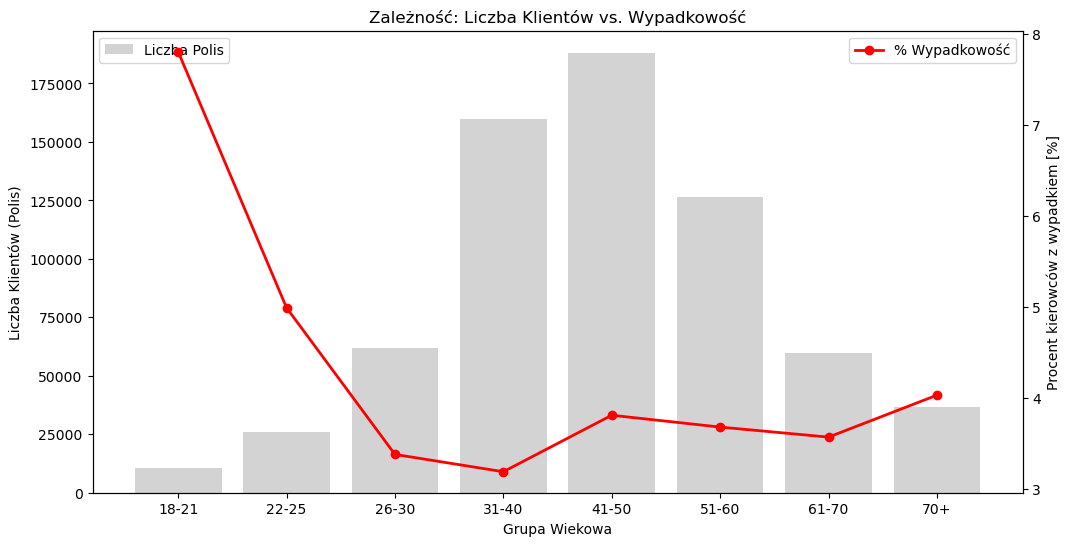

In [80]:
# ==========================================
# RAPORT SUROWYCH FAKTÓW (BEZ LOGIKI MODELU)
# ==========================================

raw_stats = merged.groupby('DRIV_AGE_BIN', observed=True).agg({
    'POLICY_ID': 'count',           # Liczba wystawionych polis
    'CLAIM_NB': 'sum',              # Łączna liczba zgłoszonych wypadków
    'CLAIM_TOTAL_AMOUNT': 'sum'     # Łączny koszt wszystkich szkód
}).reset_index()

# Obliczamy proste wskaźniki "na chłopski rozum":
# 1. Częstość surowa: Jaki % kierowców miał wypadek?
raw_stats['%_Kierowcow_ze_Szkoda'] = (raw_stats['CLAIM_NB'] / raw_stats['POLICY_ID'] * 100).round(2)

# 2. Średni koszt: Ile średnio kosztował jeden wypadek w tej grupie?
raw_stats['Sredni_Koszt_Wypadku'] = (raw_stats['CLAIM_TOTAL_AMOUNT'] / raw_stats['CLAIM_NB']).round(2)

# Zmiana nazw na bardziej czytelne
raw_stats.columns = ['Grupa_Wieku', 'Liczba_Polis', 'Liczba_Wypadkow', 'Suma_Kosztow_Szkod', '%_Wypadkowosc', 'Srednia_Szkoda']

print("\n" + "="*80)
print("SUROWE STATYSTYKI PORTFELA (FAKTY HISTORYCZNE)")
print("="*80)
print(raw_stats.to_string(index=False))

# --- WIZUALIZACJA ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Słupki: Liczba polis
ax1.bar(raw_stats['Grupa_Wieku'], raw_stats['Liczba_Polis'], color='lightgrey', label='Liczba Polis')
ax1.set_ylabel('Liczba Klientów (Polis)')
ax1.set_xlabel('Grupa Wiekowa')

# Linia: Wypadkowość (lewa oś)
ax2 = ax1.twinx()
ax2.plot(raw_stats['Grupa_Wieku'], raw_stats['%_Wypadkowosc'], color='red', marker='o', linewidth=2, label='% Wypadkowość')
ax2.set_ylabel('Procent kierowców z wypadkiem [%]')

plt.title("Zależność: Liczba Klientów vs. Wypadkowość")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

In [89]:
# ==========================================
# DODATKOWY BLOK: WYNIK TECHNICZNY (ZYSK / STRATA) - FIX MERGE KEY
# ==========================================

# 0) Ustalenie klucza segmentu w summary_final
if 'DRIV_AGE_BIN' in summary_final.columns:
    key_col = 'DRIV_AGE_BIN'
elif 'Segment (Wiek)' in summary_final.columns:
    key_col = 'Segment (Wiek)'
else:
    raise KeyError(
        "Nie znaleziono kolumny segmentu w summary_final. "
        "Oczekuję 'DRIV_AGE_BIN' albo 'Segment (Wiek)'. "
        f"Dostępne kolumny: {list(summary_final.columns)}"
    )

kpi_summary['Technical_Result'] = (
    kpi_summary['MTPL_EARNED_PREMIUM']
    - kpi_summary['CLAIM_TOTAL_AMOUNT']
    - kpi_summary['EARNED_VariableCost']
)

kpi_summary['Technical_Margin_%'] = (
    kpi_summary['Technical_Result'] / kpi_summary['MTPL_EARNED_PREMIUM']
)

# 2) Przygotowanie tabeli do merge z nazwą klucza jak w summary_final
to_merge = kpi_summary[['DRIV_AGE_BIN', 'Technical_Result', 'Technical_Margin_%']].copy()
if key_col != 'DRIV_AGE_BIN':
    to_merge = to_merge.rename(columns={'DRIV_AGE_BIN': key_col})

# 3) Merge (bezpiecznie)
summary_final = summary_final.merge(to_merge, on=key_col, how='left')

# 4) Formatowanie do prezentacji
summary_final['Wynik Techniczny [$]'] = summary_final['Technical_Result'].map(
    lambda x: f"+{x:,.0f} $" if pd.notnull(x) and x >= 0 else (f"{x:,.0f} $" if pd.notnull(x) else "NA")
)

summary_final['Marza Techniczna [%]'] = (summary_final['Technical_Margin_%'] * 100).round(2)

# 5) Sprzątanie kolumn technicznych
summary_final.drop(columns=['Technical_Result', 'Technical_Margin_%'], inplace=True)

# 6) Print
print("\n" + "="*120)
print("FINALNY RAPORT STRATEGICZNY MTPL – DODANY WYNIK TECHNICZNY (ZYSK / STRATA)")
print("="*120)
from IPython.display import display

display(summary_final)




FINALNY RAPORT STRATEGICZNY MTPL – DODANY WYNIK TECHNICZNY (ZYSK / STRATA)


,Segment (Wiek),Oferowana Cena [$],Combined Ratio [%],Sredni Koszt Wypadku [$],Wypadkowosc [%],Ryzyko Odpływu [%],Wynik Techniczny [$],Marza Techniczna [%]
0,18-21,991.059415,262.39,11294.19,7.80,97.69,"-6,524,185 $",-162.39
1,22-25,395.245879,89.39,1983.79,4.99,76.23,"+446,164 $",10.61
2,26-30,277.209652,93.82,2236.82,3.38,41.86,"+441,569 $",6.18
3,31-40,238.704145,95.91,2324.99,3.19,26.40,"+720,181 $",4.09
4,41-50,245.453926,87.21,1908.23,3.81,19.42,"+2,983,587 $",12.79
5,51-60,230.371295,86.98,1979.47,3.68,13.27,"+2,050,312 $",13.02
6,61-70,193.926756,93.37,2043.76,3.57,8.09,"+444,318 $",6.63
7,70+,236.043898,99.77,2757.96,4.03,16.90,"+13,360 $",0.23


In [92]:
TOTAL_RESULT = (
    merged['MTPL_EARNED_PREMIUM'].sum()
    - merged['CLAIM_TOTAL_AMOUNT'].sum()
    - merged['EARNED_VariableCost'].sum()
)

TOTAL_RESULT


575304.7367601059